# 01 — Data ingestion & panel construction

Builds the country × month panel of cows' milk deliveries and annotates it with
the difference-in-differences treatment and period flags.

- **Input:** Eurostat `apro_mk_colm` (live API) — cows' milk collection, monthly.
- **Output:** `data/processed/panel.parquet` — columns `geo, date, milk_deliveries, treated, post, treated_post`.
- **Pipeline position:** `01_data` → `02_eda` → `03_did` → `04_synthetic_control`.
- **Local modules:** `ingest.py`, `treatment.py` (must be importable from here).

The notebook is the *visual* layer: it inspects the live codelists, eyeballs the
parallel-trends assumption, and saves the panel. The reusable logic lives in the
`.py` modules.

In [23]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ingest
from treatment import assign_treatment, ABOLITION_DATE, BINDING_COUNTRIES
import estimation as est
import synth


In [2]:
pd.set_option("display.max_columns", 30)
PROC = Path("data/processed")
PROC.mkdir(parents=True, exist_ok=True)

## 1. Fetch the raw dataset

### What `fetch_long` returns, and why it's "long"

Eurostat ships this dataset in **wide** form, one column per month, ~570 of them. `fetch_long` reshapes it to **long** form (a `melt`): the month columns collapse into a single `time` column and a single `value` column, so every country–month becomes one row. Same information, unpivoted from a matrix into `(country, time) → value`, which is the shape that panel and plotting libraries expect (and the reason for the row count jumping to ~400k).

The eight columns are of two kinds.

**Identifier dimensions** — the coordinates that say *which series* a number belongs to:

| column | meaning | code we keep |
|---|---|---|
| `freq` | frequency | `M` (monthly) |
| `milkitem` | what is measured | `PRD` (quantity), *not* `FAT`/`PRT`, which are % fat/protein |
| `dairyprod` | which product | `D1110D` (raw cows' milk collected), others are cream, butter, cheese… |
| `unit` | unit | `THS_T` (thousand tonnes), *not* `PC` (percent) |
| `geo` | country | Eurostat codes (note: Greece = `EL`, UK = `UK`) |

**Content** — the actual data:

| column | meaning |
|---|---|
| `time` | the month as the raw Eurostat label (`2010-01`) |
| `value` | the measured number |
| `date` | `time` parsed to a real date (`2010-01-01`) for filtering, sorting, plotting |

`build_panel` then pins the identifier dimensions
(`dairyprod=D1110D`, `milkitem=PRD`, `unit=THS_T`) to isolate a **single
series** — raw milk collected, in thousand tonnes — so the only things varying
row to row are country and month: exactly the country × month panel the
analysis needs.

So, `fetch_long` function downloads `apro_mk_colm` from Eurostat and starts the process to return it in the format described above (one row per dimension combination × period).

In [3]:
# We use the fetch_long function to extract the raw data.
long = ingest.fetch_long("apro_mk_colm")
print("shape:", long.shape)
long.head()

shape: (406580, 8)


,freq,milkitem,dairyprod,unit,geo,time,value,date
0,M,FAT,D1110D,PC,AL,1968-01,NaN,1968-01-01
1,M,FAT,D1110D,PC,AT,1968-01,NaN,1968-01-01
2,M,FAT,D1110D,PC,BA,1968-01,NaN,1968-01-01
3,M,FAT,D1110D,PC,BE,1968-01,3.46,1968-01-01
4,M,FAT,D1110D,PC,BG,1968-01,NaN,1968-01-01


## 2. Confirm the dimension codes

Eurostat renames codes occasionally, so before filtering we look at what is actually in the data. From the printout below identify:

- the **product/element** code for *raw cows' milk collected* (in the product dimension, usually `dairyprod`);
- the **unit** code (e.g. thousand tonnes).

Then fill them into the cell two below.

### Why this step exists

You can't pin a code you've never seen. Eurostat codes aren't guessable (`D1110D`, `PRD`, `THS_T`) and change occasionally, so before filtering we print the "menu" of codes available in each dimension and pick from the list
rather than blindly. **We** must read it and identify the right ones.

In [4]:
# We print the different values of identifier dimensions to have a look at them and identify non important values.
dim_cols = [c for c in long.columns if c not in ("time", "date", "value")]
print("dimension columns:", dim_cols, "\n")
for d in dim_cols:
    vals = ingest.inspect_codes(long, d)
    preview = vals if len(vals) <= 25 else vals[:25] + ["..."]
    print(f"{d}  ({len(vals)} codes):\n  {preview}\n")

dimension columns: ['freq', 'milkitem', 'dairyprod', 'unit', 'geo'] 

freq  (1 codes):
  ['M']

milkitem  (3 codes):
  ['FAT', 'PRD', 'PTEN']

dairyprod  (10 codes):
  ['D1110D', 'D1200DME', 'D2100', 'D2200V', 'D3100_X_3113', 'D3113', 'D3200', 'D4100', 'D6000', 'D7121']

unit  (2 codes):
  ['PC', 'THS_T']

geo  (46 codes):
  ['AL', 'AT', 'BA', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EEA', 'EFTA', 'EL', 'ES', 'EU', 'EU15', 'EU25', 'EU27_2007', 'EU27_2020', 'EU28', 'FI', 'FR', 'HR', 'HU', '...']



We can see here the `dairyprod` dimension has irrelevant values a part from the interesting `D1110D`, the `milkitem` dimension (`FAT` / `PRD` / `PRT`) and that `unit` carried `PC` as well as `THS_T`. Since we are only interested in `PRD` for `milkitem` and `THS_T` for `unit` we add this information to `ingest` function through `MILK_DELIVERIES`.

We will use then to filter the dataset and to just keep the values of interest in `identifier dimensions`.

## 3. Build the country × month panel

### Isolating a single series

The long table doesn't hold one series, it holds *many* stacked on top of each other: every combination of product × item × unit is in there (raw milk, butter, cheese; quantities and fat/protein percentages). A panel, by contrast, needs **exactly one outcome value per country-month**. So the task here is to collapse that stack down to a single series.

The governing principle is strict: a valid panel has one value per `(geo, time)`. That holds only if *every* identifier dimension except `geo` and `time` is pinned to a single code. Leave one unpinned and the rows silently stack-mixing, say, fat-percentage with tonnes, and nothing downstream will error; it will just be quietly wrong. That failure mode (a plausible-looking but corrupted number) is the one worth engineering against.

So we pin the three identifiers to the outcome we want, raw cows' milk collected, in thousand tonnes (`dairyprod=D1110D`, `milkitem=PRD`, `unit=THS_T`), frozen in `ingest.MILK_DELIVERIES` so the choice is documented
once rather than scattered across cells. And rather than trust that the pinning is complete, `build_panel` **asserts** at most one row per country-month after filtering; if more than one survives, it fails loud and names the dimension still left open. We'd rather halt than average two series by accident.

In [5]:
# We use the MILK_DELIVERIES to filter the dataset to keep the interesting values of identifier dimensions.
panel = ingest.build_panel(long, filters=ingest.MILK_DELIVERIES)
print("panel shape:", panel.shape)
panel.head()

panel shape: (14077, 3)


,geo,date,milk_deliveries
0,AL,2015-01-01,0.0
1,AL,2015-02-01,0.0
2,AL,2015-03-01,0.0
3,AL,2015-04-01,0.0
4,AL,2015-05-01,0.0


### What the panel reveals and the decision it forces

The shape is right: one row per country-month, values in thousand tonnes. But inspecting the result surfaces a problem that the data source handed us silently, the country list contains **non-EU geographies**. Eurostat reports
candidate and third countries (Albania, Norway, Switzerland, Serbia…) alongside the Member States, and several show `0.0` deliveries (no industrial collection reported).

This matters on two levels:

- **Identification.** The control group only works if it's a credible counterfactual: countries under the same EU   conditions but untouched by the quota. Albania or Serbia have entirely different market structures, they are not the world the treated countries would have lived in absent the abolition. Admitting them contaminates the control.
- **Mechanics.** Those `0.0` pre-period values would break the index normalisation in the parallel-trends check (dividing by a zero pre-2015 mean → infinity) and distort the group averages.

The deeper point is methodological: **the set of units in a causal study is a design decision, not whatever the data source happens to ship.** Letting the data dictate the sample is precisely how invalid controls slip in unnoticed.

So the next step defines an explicit analysis universe — EU-28, the 12 treated plus 16 valid controls, and drops everything outside it. That restriction lives in the treatment step (next section), keeping ingestion generic and the
design choice sitting with the design code.

## 4. Assign treatment and period

### From "everyone was treated" to a treatment and a control

A natural objection sits at the centre of this design: the abolition applied to all 28 Member States on the same day,so how can there be a control group? If everyone received the intervention, what is left to compare against?

The resolution is the conceptual core of the study. The *formal* policy (the quota ended everywhere) is not the *effective* treatment. Removing a constraint only changes behaviour where the constraint was actually binding. A country producing far below its quota had no brake to release, the abolition was a non-event for it. A country pressed against its quota, or paying the superlevy to exceed it, suddenly had the brake lifted. So the effective treatment is **"having had a binding quota,"** and that is what splits the 28.

This fixes what `treated` is: a property of the **country, constant over time**, not something computed observation by observation. A country either was or wasn't constrained; that status doesn't change month to month.

Two design choices follow, both stated openly because both are only defensible once declared:

- **We encode the documented list of 12 binding Member States rather than reconstructing it.** The rigorous definition of "binding" is a pre-abolition quota fill rate (deliveries / national quota) near or above 100%. Computing it ourselves needs the historical national-quota series, which Eurostat doesn't publish cleanly. The published list was built from exactly that criterion, so we adopt it as the primary definition and keep the fill-rate reconstruction as a robustness check. The simplification is named, not hidden.
- **We restrict to an explicit EU-28 universe (12 treated + 16 control).** The decision motivated when the previous section surfaced non-EU geographies. The restriction belongs here, with the design code, not in the generic ingestion.

`post` is the time switch at the April-2015 break, and `treated × post` is their interaction, the single term whose coefficient will carry the causal estimate once country and month fixed effects absorb everything else. And because a
mislabelled geo code would silently corrupt the split, the step **fails loud** if any of the 12 binding countries is missing: the cheapest insurance against the `EL`/`UK` trap.

In [6]:
# We use assign_treatment to create a panel with only the explicit EU-28 universe.
panel = assign_treatment(panel)
print("countries by group:")

# We print the countries by the treated value.
print(panel.groupby("treated")["geo"].nunique().rename({0: "control", 1: "treated"}))
panel.head()

countries by group:
treated
control    16
treated    12
Name: geo, dtype: int64


,geo,date,milk_deliveries,treated,post,treated_post
108,AT,1995-01-01,181.0,1,0,0
109,AT,1995-02-01,173.0,1,0,0
110,AT,1995-03-01,199.0,1,0,0
111,AT,1995-04-01,196.0,1,0,0
112,AT,1995-05-01,221.0,1,0,0


### A clean split and the assumptions it now rests on

The split is exactly 12 treated and 16 control, and the assertion that the treated set is precisely the 12 binding countries passed: the universe is clean and the labels are where they belong. Mechanically, the design is assembled.

But it's worth being explicit about what this assignment quietly assumes, each simplification is a place the analysis could be challenged, and naming them first is the point:

- **Treatment is binary, but "binding" is a matter of degree.** A country at 99% quota fill and one paying heavy superlevy are both coded `1`, yet the policy bit them differently. The binary split is the defensible primary   specification; the continuous fill-rate intensity is the robustness check that will test whether the conclusion survives a more granular treatment.
- **The average effect will hide real heterogeneity.** Among the treated, Ireland, the Netherlands and Germany expanded far more than the rest. A single average treatment effect is a fair headline, but that spread is itself a  finding, and motivates the heterogeneous-effects extension later.
- **Two controls are on probation.** Croatia joined the EU only in 2013 (short, partial pre-period) and Malta has negligible industrial collection. They stay in for now, but as candidates to trim, a call to be made by the pre-treatment fit, not by hand.

The deeper point: this step has *assigned* treatment, but it has not *earned* the causal interpretation. Everything now rests on parallel trends, that absent the abolition, the two groups would have moved together. That is an assumption, not a result, and the next section puts it to the test. If the treated group is already diverging before 2015, the clean 12/16 split won't save the design; the design itself will need revising.

## 5. Sanity checks

### Auditing the panel before trusting it

The most dangerous data error is not the one that crashes, it's the one that produces a plausible-looking number. A wrong sample, an unbalanced panel or hidden missingness won't raise an exception; they'll quietly bias a causal estimate that we then present with confidence. So before any plot or regression, we audit the panel against what we *believe* it to be. The check is cheap; an undetected error downstream is not.

Each check targets a specific failure mode, not a generic "does it look ok":

- **Date range**: confirms the time parsing worked and the coverage is what we expect (no truncation, no stray dates from a malformed label).
- **Country count and the two group lists**: confirms the EU-28 restriction took effect (28 = 12 + 16) and that each country sits in the right group. The `assert` here is deliberate: a mislabelled geo code (the `EL`/`UK` trap) would corrupt the entire treated/control split, so we'd rather halt than proceed on a silently wrong sample.
- **Observations per country (min/median/max)** a balance check. A large spread means some countries are observed far longer than others, which bears directly on the design and on how we window the data.
- **Missing deliveries**, confirms no NaNs survive into the estimation set.

The thread running through all four: trust nothing about the data that we haven't explicitly verified. This is the same fail-loud, audit-first stance as the safeguards in `build_panel` and `assign_treatment`, applied now to the
assembled panel as a whole.

In [7]:
print("date range :", panel.date.min().date(), "→", panel.date.max().date())
print("n countries:", panel.geo.nunique())
print("treated    :", sorted(panel.loc[panel.treated == 1, "geo"].unique()))
print("control    :", sorted(panel.loc[panel.treated == 0, "geo"].unique()))

counts = panel.groupby("geo").size()
print("\nobs per country  min/median/max:",
      counts.min(), int(counts.median()), counts.max())
print("missing deliveries:", int(panel.milk_deliveries.isna().sum()))

expected = set(BINDING_COUNTRIES)
got = set(panel.loc[panel.treated == 1, "geo"].unique())
assert got == expected, f"treated set mismatch: {expected ^ got}"

date range : 1968-01-01 → 2026-05-01
n countries: 28
treated    : ['AT', 'BE', 'CY', 'DE', 'DK', 'EE', 'ES', 'IE', 'IT', 'LU', 'NL', 'PL']
control    : ['BG', 'CZ', 'EL', 'FI', 'FR', 'HR', 'HU', 'LT', 'LV', 'MT', 'PT', 'RO', 'SE', 'SI', 'SK', 'UK']

obs per country  min/median/max: 197 376 700
missing deliveries: 0


### What the checks confirm and the one number not to trust at face value

The split is exactly **12 treated / 16 control** and the `assert` passed: the universe is clean and the labels are correct. The treated set is precisely the twelve binding Member States. Structurally, the panel is sound and ready.

Two results, though, are less a "pass" than a hand-off to the next decision:

- **Date range 1968–2026, and observations per country ranging 197 → 700.**
  That spread is large by design of the *source*, not a defect: 700 months is ~58 years (data from the late 1960s), while the 197-month minimum is ~16 years, almost certainly Croatia, which joined the EU only in 2013. A panel this
  unbalanced (some countries with half a century, others with sixteen years) is exactly the argument for windowing: a long pre-period adds rows, not comparability, and pre-2015 "parallelism" across such different histories is
  neither plausible nor relevant to a 2015 shock.

- **`missing deliveries: 0`, true, but not as reassuring as it reads.**
  This does not mean the panel has no gaps; it means `build_panel` already dropped NaN rows upstream. So the zero reflects our own filtering, not verified completeness. The real test is whether each country has an *unbroken* monthly series inside the window we choose, a country could be missing whole months and still show "0 missing" here, simply because those rows never made it into the panel. Taking a clean-looking aggregate at face value is precisely the trap these checks exist to avoid.

So the audit does its job by *generating* the next task rather than closing the book: restrict to 2010–2019, and then verify that every country has its full 120 months within that window, with Croatia (and tiny Malta) the prime
suspects for a gap. Only once that holds have we earned the right to read the parallel-trends plot.

## 6. Windowing the time and tie gaps

### Choosing the estimation window: 2010–2019

The panel spans 1968–2026, but here more data is a liability, not an asset. The window is a design decision, and it follows directly from what identifies the effect.

Difference-in-differences rests on **parallel trends**: absent the abolition, treated and control would have moved together. That is a claim about a counterfactual, and its plausibility *decays with distance from the event*.Reaching into the 1970s–90s drags in regime changes, successive CAP reforms, EU enlargements, the introduction and tightening of the quota itself, under which "parallelism" is neither credible nor relevant to a 2015 shock. A longer
pre-period buys rows, not identification.

The window should be short enough that the two groups are structurally comparable, yet long enough to (i) read a pre-trend and (ii) trace the post-treatment dynamic. A roughly symmetric band around the April-2015 break does both:

- **Upper bound 2019**: stop before COVID. The 2020 pandemic is a large, quota-unrelated shock to dairy demand and supply chains; letting it into the post-period would confound the very effect we want to isolate.
- **Lower bound 2010**: five pre-treatment years, enough to establish the trend and to expose the quota "soft landing" (the gradual, pre-announced phase-out from 2008/09), while keeping the panel balanced and comparable.

The window is **provisional, not assumed**. It is only valid if, inside it, every country has an unbroken monthly series, otherwise a "balanced" window is an illusion. Hence the completeness check below: a country could be silently
missing months and still have looked fine in the earlier "0 missing" aggregate.

In [8]:
# We define the time window in WINDOW to just keep the data in this time interval.
WINDOW = ("2010-01-01", "2019-12-31")
panel = panel[panel.date.between(*pd.to_datetime(WINDOW))].reset_index(drop=True)
print("window:", panel.date.min().date(), "→", panel.date.max().date(),
      "| rows:", len(panel))

# We check if every country have an unbroken 120-month series in the window.
n_months = panel.groupby("geo").size()
incomplete = n_months[n_months < 120]
print("months per country  min/max:", n_months.min(), n_months.max())
if len(incomplete):
    print("countries with gaps in the window:\n", incomplete)
else:
    print("all countries have the full 120 months")

window: 2010-01-01 → 2019-12-01 | rows: 3300
months per country  min/max: 73 120
countries with gaps in the window:
 geo
EE    119
LU    108
MT     73
dtype: int64


### Diagnosing the gaps before deciding what to do with them

The completeness check didn't come back clean: Estonia (119/120), Luxembourg (108/120) and Malta (73/120) are missing months. Croatia, the prime suspect, is *not* on the list, it has its full series, so that worry is gone. But a count of missing months is not enough to act on: the same number means different things depending on **who** is missing it and **where** it falls. This cell exists to recover the *where*, because the decision rule depends on it.

Two principles govern what we do with an incomplete country:

- **Treated vs. control are not symmetric.** A control country is a *choice*, if it's a poor counterfactual we can   drop it and the design only gets cleaner. A treated country is part of the effect we are measuring; dropping it changes the question, so it stays unless the data is unusable.
- **An isolated gap is harmless to DiD, but not to synthetic control.** A fixed-effects regression handles an unbalanced panel without flinching, it simply uses the observations present, so a missing month or two costs nothing. Synthetic control is stricter: it needs *complete* pre-2015 series to compute the donor weights that reproduce each treated unit's trajectory. The same gap can therefore be tolerable for one method and disqualifying for another, which means "drop or keep" may actually be "keep for DiD, handle separately for synthetic control."

Crossing those two principles already resolves two of the three cases:

- **Malta**: control, and missing 39% of the window, on top of negligible  industrial collection. A small, sector-irrelevant country missing four months in ten is noise, not a counterfactual. Clear drop.
- **Estonia**: treated, missing a single month. Immaterial; it stays.

**Luxembourg is the one genuine judgement call**: treated (so not dropped lightly), but missing 12 months (~10%), no longer negligible. And the right call depends entirely on *where* those months sit. Twelve scattered months are benign; twelve consecutive months in the pre-2015 period would wreck the parallel-trends reading for Luxembourg specifically. We can't decide from a count, we have to see the dates. Hence this cell: list the exact missing months for the three countries, so the Luxembourg decision is made on the evidence rather than by eye.

In [9]:
# We check when the time gaps happen in the 3 identified countries.
full = pd.date_range("2010-01-01", "2019-12-01", freq="MS")
for g in ["EE", "LU", "MT"]:
    have = set(panel.loc[panel.geo == g, "date"])
    miss = [d.date() for d in full if d not in have]
    print(f"{g}: {len(miss)} missing -> {miss}")

EE: 1 missing -> [datetime.date(2010, 1, 1)]
LU: 12 missing -> [datetime.date(2019, 1, 1), datetime.date(2019, 2, 1), datetime.date(2019, 3, 1), datetime.date(2019, 4, 1), datetime.date(2019, 5, 1), datetime.date(2019, 6, 1), datetime.date(2019, 7, 1), datetime.date(2019, 8, 1), datetime.date(2019, 9, 1), datetime.date(2019, 10, 1), datetime.date(2019, 11, 1), datetime.date(2019, 12, 1)]
MT: 47 missing -> [datetime.date(2010, 1, 1), datetime.date(2010, 2, 1), datetime.date(2010, 3, 1), datetime.date(2010, 4, 1), datetime.date(2010, 5, 1), datetime.date(2010, 6, 1), datetime.date(2010, 7, 1), datetime.date(2010, 8, 1), datetime.date(2010, 9, 1), datetime.date(2010, 10, 1), datetime.date(2010, 11, 1), datetime.date(2010, 12, 1), datetime.date(2011, 1, 1), datetime.date(2011, 2, 1), datetime.date(2011, 3, 1), datetime.date(2011, 4, 1), datetime.date(2011, 5, 1), datetime.date(2011, 6, 1), datetime.date(2011, 7, 1), datetime.date(2011, 8, 1), datetime.date(2011, 9, 1), datetime.date(2011, 

### Resolving the gaps on evidence, not on counts

Locating *where* the missing months fall resolved all three cases, and in one of them it reversed the diagnosis a raw count would have given. This is the payoff of looking instead of applying a blanket "drop anything incomplete" rule.

- **Estonia stays, untouched.** A single missing month, January 2010: the first month of the window, far from 2015. It touches neither the pre-trend reading nor the effect. Immaterial.

- **Malta dropped from the control group.** The 47 missing months are a solid block from 2010 to 2013: Malta simply doesn't report industrial collection until 2014. As a control it has *no pre-treatment period* to establish parallel trends against, it cannot serve as a counterfactual at all, and it is a negligible producer besides.Removing it makes the design cleaner, not weaker.

- **Luxembourg stays, with the feared scenario ruled out.** The risk we flagged was a block of missing months in the *pre*-period, which would have wrecked Luxembourg's parallel-trends reading. The evidence shows the opposite: the 12 missing months are all of **2019**, the tail of the *post*-period. Luxembourg's pre-treatment series is complete and it captures the policy response from 2015 through 2018; it only loses the final follow-up year. For the main DiD this costs nothing. Two minor notes for later: its post-period is truncated at 2018 for synthetic control (decide then whether to clip its window), and it contributes nothing to any long-run 2019 estimate.

The asymmetry between treated and control did the deciding work: Malta, a control, is droppable; Estonia and Luxembourg, treated, are part of the effect and stay unless the data is unusable, which, once we saw the dates, it wasn't.

**Resulting sample: 12 treated, 15 control**, mildly unbalanced, which thefixed-effects DiD handles without issue.

In [10]:
# We delete Malta from the dataset.
panel = panel[panel.geo != "MT"].reset_index(drop=True)
print("countries:", panel.geo.nunique(), "| control:", 
      panel.loc[panel.treated == 0, "geo"].nunique(),
      "| treated:", panel.loc[panel.treated == 1, "geo"].nunique())

countries: 27 | control: 15 | treated: 12


The panel is now ready for the test the whole design has been deferring to: parallel trends.

## 6. First look to parallel trends

### The test the whole design defers to: parallel trends

Every previous step *assigned* treatment; none of it *earned* the causal reading. That right is granted only by the parallel-trends assumption: absent the abolition, treated and control would have moved together. Nothing we've done can prove it, but the pre-2015 period is observable, and there the assumption makes a checkable prediction: before the policy, the two groups should trend in parallel.

We read it on the **indexed** series (each country rescaled to its own pre-2015 mean = 100), not on levels. Levels differ by an order of magnitude, the treated are the large northern producers, and that gap is irrelevant. What must match is the *rate of change*, and indexing strips out the level so the eye compares trends, not sizes.

What each outcome would mean is worth committing to *before* looking, so the read isn't rationalised after the fact:

- **Parallel before 2015, diverging after**, the assumption holds, the control is a credible counterfactual, and we proceed to estimation.
- **Already diverging before 2015**, this would *not* be a data error but a real finding: the fingerprint of the quota "soft landing," the pre-announced, gradual phase-out that let treated countries expand in anticipation. It would invalidate a naive single-break DiD and force the design to change (extend the pre-period, shift the effective treatment date, or model treatment as anticipated). The design would yield to the evidence, not the reverse.

One caveat about *how* we look. Milk production is strongly seasonal (a spring peak), so the raw indexed lines are jagged, and seasonality could mask or fake a trend by eye. The smoothing below is a **visual aid only**, the estimation itself removes seasonality properly, through month fixed effects, never by altering the data.

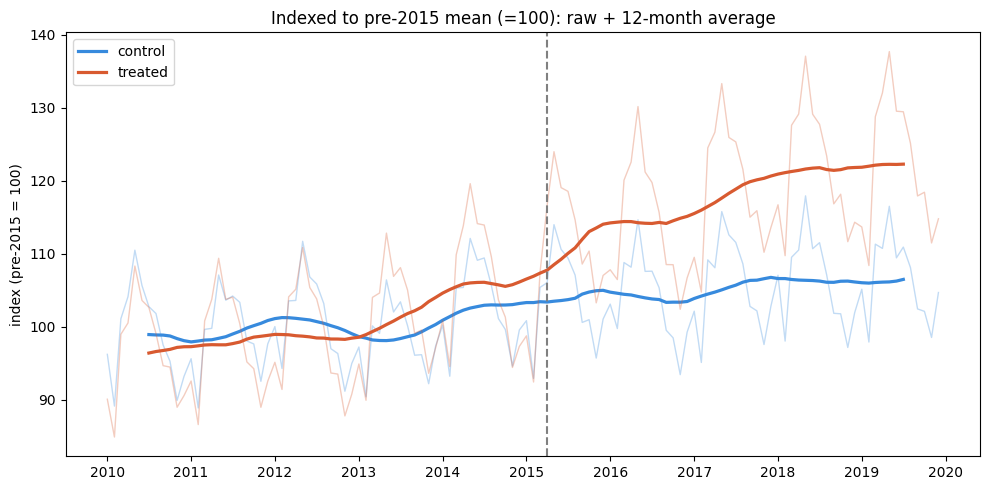

In [11]:
# index each country to its own pre-2015 mean, then average within group
pre = panel[panel.date < ABOLITION_DATE]
base = pre.groupby("geo")["milk_deliveries"].mean()
panel["idx"] = panel["milk_deliveries"] / panel["geo"].map(base) * 100

gi = (panel.groupby(["date", "treated"])["idx"].mean()
            .unstack("treated").rename(columns={0: "control", 1: "treated"}))

fig, ax = plt.subplots(figsize=(10, 5))
for col, color in [("control", "#378ADD"), ("treated", "#D85A30")]:
    ax.plot(gi.index, gi[col], color=color, alpha=0.30, lw=1)                 # raw
    ax.plot(gi.index, gi[col].rolling(12, center=True).mean(),
            color=color, lw=2.3, label=col)                                   # 12-month avg
ax.axvline(ABOLITION_DATE, ls="--", color="grey")
ax.set(title="Indexed to pre-2015 mean (=100): raw + 12-month average",
       ylabel="index (pre-2015 = 100)")
ax.legend(); plt.tight_layout(); plt.show()

### Reading the test: a strong effect, but trends are not cleanly parallel

Two things are visible, and honesty requires holding both at once.

**The post-2015 signal is unambiguous.** After the break the treated group climbs steeply, ~108 to ~122 by 2019, while control rises only to ~106. The gap is large and sustained; an effect of the abolition is clearly present.

**But the pre-2015 trends are not flat-parallel.** From around 2013–2014 the treated smoothed line drifts above control *before* the policy date, opening a gap of a few index points by April 2015. In 2010–2012 the groups track closely; the separation starts in the last pre-treatment years. This is exactly the pattern we committed, in advance, to naming for what it is: the **soft-landing / anticipation effect**, treated countries expanding ahead of a pre-announced, gradually phased-out quota, not reacting to a clean 2015 shock.

This is a finding, not a failure, but it has a hard consequence: **a naive single-break DiD would be biased upward**, crediting the policy with divergence already underway before it took effect. The plot is therefore not a green light to read off a single coefficient.

What it sets up is the next step. The eye and a 12-month smoother can exaggerate, so the pre-trend must be *quantified* before any estimate is trusted. That is what an **event study** does: a separate coefficient per period
relative to 2015, turning "the lines seem to drift" into a test, are the pre-2015 coefficients distinguishable from zero? If so, we model the anticipation explicitly (shift the effective treatment date, or treat the intervention as gradual) rather than pretend the break is sharp. The design yields to the evidence, as promised.

## 7. The event study

### From a suspicion to a test: the event study

The smoothed plot suggests the treated group drifts upward before 2015, but a 12-month rolling mean can manufacture or hide a trend, the eye is not evidence. The event study turns that suspicion into a measurement.

A single-coefficient DiD compresses the whole post-period into one number. The event study unpacks it along time: one treated-vs-control coefficient **per year**, each relative to a fixed baseline. We omit **2014**, the last full
pre-treatment year, so every coefficient reads as the treated–control gap in that year *relative to 2014* (the 2014 coefficient is therefore 0 by construction, not a result).

That structure puts numbers on both things we care about, with the interpretation fixed *before* looking:

- **Pre-2015 coefficients (2010–2013).** Under parallel trends these should be indistinguishable from zero: no systematic gap before the policy. If 2013 is already positive and significant, that is the soft-landing anticipation, quantified, not an artefact of smoothing.
- **Post-2015 coefficients (2016–2019).** These trace the dynamic effect: how the gap opens and whether it keeps widening.

Two specification choices, stated plainly:

- **Outcome is log deliveries, not the indexed series.** Indexing was a *visual* device. In the regression, country fixed effects absorb the level gaps directly, and a log outcome makes each coefficient an approximate percentage effect, the principled version of "compare rates, not levels."
- **Fixed effects: country + month.** Country FE remove fixed structural differences; monthly time FE absorb everything common across countries in a given month, seasonality, and crucially the concurrent confounders (the 2014 Russian import ban, the 2015–16 price crash), to the extent they hit both groups alike. Standard errors are clustered by country (deliveries are serially correlated month to month).

One honest caveat: **2015 straddles the break** (quota until March, gone from April), so its annual coefficient mixes three treated-free months with nine treated ones, read it as transitional. The parallel-trends verdict rests on
2010–2013, which are clean.

###

Estimation:  OLS
Dep. var.: log_milk, Fixed effects: geo + date
sample: None = all
Inference:  CRV1
Observations:  3227

| Coefficient        |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| year::2010:treated |     -0.052 |        0.028 |    -1.831 |      0.079 | -0.110 |   0.006 |
| year::2011:treated |     -0.042 |        0.024 |    -1.793 |      0.085 | -0.091 |   0.006 |
| year::2012:treated |     -0.052 |        0.019 |    -2.762 |      0.010 | -0.091 |  -0.013 |
| year::2013:treated |      0.001 |        0.012 |     0.067 |      0.947 | -0.023 |   0.025 |
| year::2015:treated |      0.028 |        0.015 |     1.834 |      0.078 | -0.003 |   0.059 |
| year::2016:treated |      0.065 |        0.027 |     2.424 |      0.023 |  0.010 |   0.120 |
| year::2017:treated |      0.088 |        0.033 |     2.674 |      0.013 |  0.020 |   0.155 |
| year::2018:treate

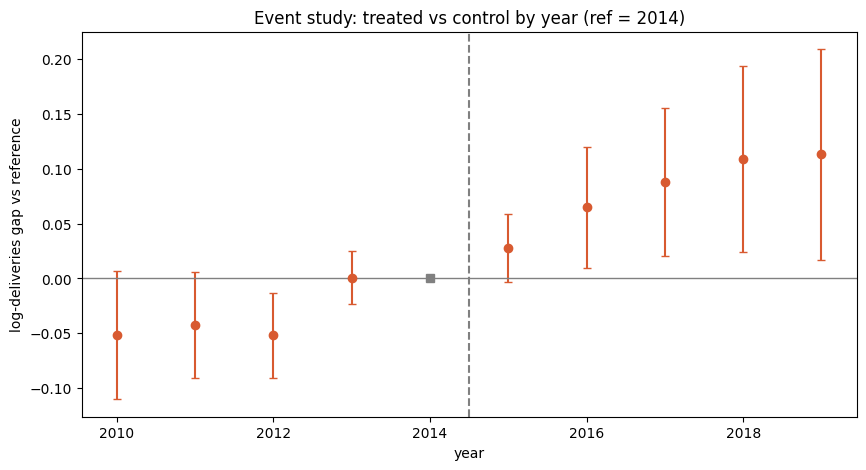

In [12]:
# We run the study event for reference year 2014.
es = est.run_event_study(panel, ref_year=2014)
es.summary()

# We plot the coefficients.
est.plot_event_study(es)
plt.show()

###

Estimation:  OLS
Dep. var.: log_milk, Fixed effects: geo + date
sample: None = all
Inference:  CRV1
Observations:  3227

| Coefficient        |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| year::2010:treated |     -0.053 |        0.023 |    -2.327 |      0.028 | -0.099 |  -0.006 |
| year::2011:treated |     -0.043 |        0.019 |    -2.242 |      0.034 | -0.083 |  -0.004 |
| year::2012:treated |     -0.053 |        0.013 |    -3.958 |      0.001 | -0.080 |  -0.025 |
| year::2014:treated |     -0.001 |        0.012 |    -0.067 |      0.947 | -0.025 |   0.023 |
| year::2015:treated |      0.027 |        0.016 |     1.645 |      0.112 | -0.007 |   0.061 |
| year::2016:treated |      0.064 |        0.026 |     2.421 |      0.023 |  0.010 |   0.118 |
| year::2017:treated |      0.087 |        0.034 |     2.597 |      0.015 |  0.018 |   0.156 |
| year::2018:treate

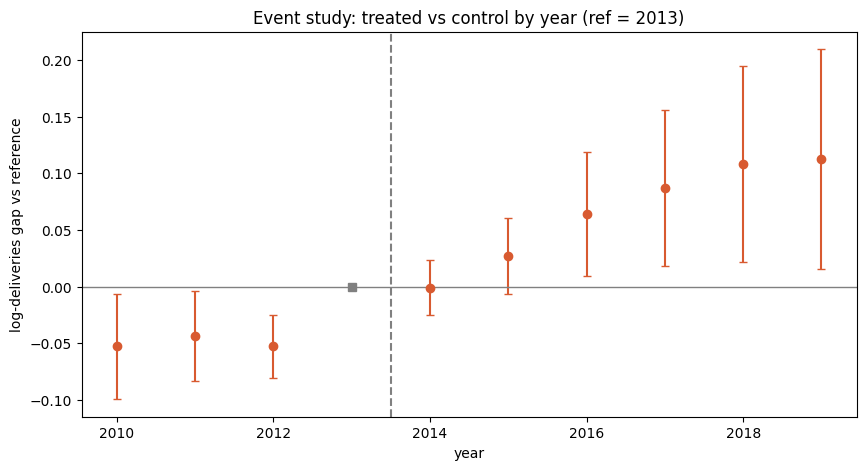

In [13]:
# We run the study event for reference year 2013.
es = est.run_event_study(panel, ref_year=2013)
es.summary()

# We plot the coefficients.
est.plot_event_study(es)
plt.show()

### Reading the event study: a clear effect, with the pre-trend declared honestly

The smoothed plot earlier *suggested* the treated group drifted upward before 2015; the event study corrects that impression with numbers. Each coefficient is the treated–control gap in log deliveries for that year, relative to 2014. Two findings, held together without varnish.

**The post-2015 effect is a textbook dynamic treatment effect.** From the break the gap opens monotonically, roughly +3% (2015, transitional), +6.5%, +8.8%, +11%, +12% by 2019, all post-2016 coefficients significant at 5%. The 2015
coefficient is weaker (p≈0.08) precisely because that year straddles the cutoff (quota through March, gone from April), so it should be read as transitional. The gradual, sustained build-up is exactly the shape a real supply response to a lifted constraint should take.

**The pre-trend is not flat, and we say so.** The naive single-break reading fails a strict parallel-trends test: 2010–2012 sit significantly *below* the 2014 baseline (2012 at p≈0.01). But the *shape* matters more than the test
verdict. This is **not** the accelerating ramp that anticipation (the soft landing) would produce, coefficients climbing ever more positive into 2015. It is the opposite: an early *deficit* that *closes*, with 2013 and 2014 flat
against each other, after which the post-2015 rise is a new, distinct movement. The most plausible source is the recovery from the 2009 dairy-price crash, which hit the large northern exporters (our treated group) hardest, not the policy.

**Two robustness facts that strengthen the read:**

- **The effect doesn't depend on the reference year.** Re-anchoring on 2013 instead of 2014 leaves the post coefficients identical to the third decimal (2016: 0.064 vs 0.065; 2019: 0.112 vs 0.113), as expected since 2013 and 2014 are flat against each other. Only the pre-period significances shift slightly, reflecting a tighter anchor, not a different result.
- **The pre-trend bias, if any, runs against us.** The treated group was *below* control before treatment, so a lingering pre-trend would, if anything, *understate* the effect, the +12% is therefore conservative, not inflated.

**Where this leaves the design.** The effect is real and economically large, but the imperfect pre-trend means difference-in-differences alone cannot fully carry the causal claim, and pretending otherwise would be the kind of overclaim this project is built to avoid. The honest next step is a method that does **not** assume parallel trends: synthetic control, which matches each treated country's *entire* pre-2015 trajectory to build its counterfactual, and so absorbs the 2010–2012 deficit by construction. If it returns an effect in the same +10–12% range, the result is triangulated and robust despite the pre-trend. That convergence, not a single coefficient, is the claim worth making.

## 8. Synthetic control

## Second method: synthetic control

The event study left the design in a specific place: a large, credible post-2015 effect, but an imperfect pre-trend(the 2010–2012 deficit). DiD rests on parallel trends, which here only partly holds, so a single method cannot carry the causal claim. We need a *second* estimate built on *different* assumptions, if both agree, the conclusion doesn't depend on the assumption that wobbles.

Synthetic control is that method, and it is the right one for this specific weakness. Instead of averaging all controls and assuming they move parallel to the treated (DiD), it builds, for each treated country, a bespoke counterfactual, a weighted combination of control countries chosen to reproduce *that country's own* pre-2015 trajectory. It therefore **does not assume parallel trends**; it reconstructs each treated unit's pre-period path
directly, absorbing the 2010–2012 deficit by construction.

Design choices, each stated to be defended:

- **One synthetic control per treated country (12), donors = the 15 controls.**Never other treated units (contaminated by the same policy). Fitting each separately also exposes the country-level heterogeneity we expect.
- **Convex weights (w ≥ 0, sum w = 1).** The counterfactual is an interpolation *inside* the donor convex hull, a mix of real countries, never an extrapolation like "Ireland × 3 − France × 2". This is Abadie's key safeguard against fantasy counterfactuals.
- **Match on the monthly pre-2015 log path (2010–2014).** Logs so the gap reads, as a ~% effect, directly comparable to the DiD's +12%.

The treated-minus-synthetic **gap** is the estimate: flat near zero before 2015 (a good synthetic reproduces the past), opening up after if the policy had an effect. The pre-period gap is also the built-in honesty check, if it is *not* flat, the synthetic failed and its post gap is not to be trusted.

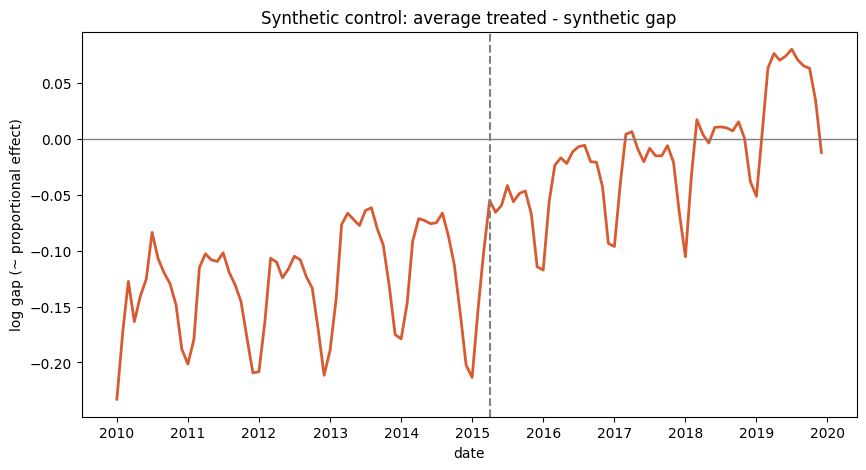

mean effect post (log): -0.015


In [14]:
# We obtain the conterfactual clones for each threated country.
results, gaps, avg_gap = synth.run_all_treated(panel, pre_end="2014-12-01")

# We plot the average effect over time
synth.plot_average_gap(avg_gap)
plt.show()

# Size of the effect in the post period (average log gap ≈ % effect)
print("mean effect post (log):", round(avg_gap[avg_gap.index >= "2015-04-01"].mean(), 3))

In [15]:
# We have a look to the effects per country.
synth.post_effects(gaps).round(3)

IE    0.272
DE    0.269
PL    0.132
NL    0.126
BE    0.103
DK    0.091
ES    0.081
IT    0.056
AT    0.052
EE    0.002
LU   -0.436
CY   -1.024
dtype: float64

In [16]:
# Also we have a look to the RMSPE.
rmspe = pd.Series({u: r["pre_rmspe"] for u, r in results.items()}).sort_values()
print(rmspe.round(3))

BE    0.016
DK    0.020
AT    0.020
ES    0.024
NL    0.029
PL    0.041
IT    0.043
EE    0.048
DE    0.213
IE    0.516
LU    0.577
CY    1.185
dtype: float64


### Where the standard synthetic control breaks and why

Read the diagnostic, not just the headline number. The naive average effect came out near zero, but that figure is poisoned, and the *reason* is the finding.

The pre-period gap is **not flat**, it sits well below zero (≈ −0.20/−0.10) throughout 2010–2014. A synthetic control is supposed to reproduce the pre-period almost exactly; a large pre gap means the counterfactual is failing *before* the policy, which makes any post gap uninterpretable. The plot istelling us not to trust it.

The per-country pre-RMSPE makes the failure precise, and corrects an intuition that the post-period signs alone would have suggested: a coefficient with a "plausible" sign can be as badly fit as one giving nonsense. There is a compact, well-fitting group (BE, DK, AT, ES, NL, PL, IT, EE, RMSPE 0.016–0.048) and then a sharp jump, **DE 0.21, IE 0.52, LU 0.58, CY 1.18**. Crucially, this includes Germany and Ireland: the two largest expanders, the protagonists of the story, are among the worst-fit.

The cause is structural, not a bug. Convex weights confine the synthetic to the donors' convex hull. Germany is the EU's largest producer and Ireland grew explosively, both lie at the *edge of or outside* that hull, so **no convex mix
of controls can reach them**. The no-extrapolation property that protects against fantasy counterfactuals is exactly what prevents fitting extreme units.

This is a known limitation of standard synthetic control with extreme treated units, and naming it via pre-RMSPE, rather than reporting a falsely clean number, is the point. It also forces a choice. Restricting to the well-fit units gives an honest but partial answer (it excludes the biggest effects). Instead we adopt the **augmented (ridge) synthetic control**, which relaxes the non-negativity constraint to permit *regularised* extrapolation, controlled
enough to reach DE and IE without inventing wild counterfactuals, and we judge whether it helped by the same objective gauge: does their pre-RMSPE drop into the well-fit range?

## 9. Augmented (ridge) synthetic control

### Augmented synthetic control: extrapolating, with a leash

The standard synthetic control failed exactly where it matters: the largest producers (Germany, Ireland) had pre-RMSPE 5–25× the well-fit group. The cause was structural, not incidental, convex weights confine the synthetic to the donors' convex hull, and units at the edge of that hull cannot be reached by any mix of controls. Dropping them would leave the biggest effects unvalidated, so instead we relax the binding constraint.

The augmented (ridge) synthetic control keeps the same objective, reproduce each treated unit's pre-2015 path, but **drops the non-negativity constraint**, so weights may be negative. A negative weight is extrapolation: it lets the
synthetic climb *above* every donor to reach a unit like Germany, which pure interpolation never could. Unconstrained, that freedom would overfit the pre-period and produce wild counterfactuals, so it is leashed by a ridge penalty λ‖w‖²: small λ allows more extrapolation (lower bias, higher variance), large λ pulls back toward stability. This is the bias–variance trade-off made explicit, and λ is chosen by pre-period cross-validation rather than by hand.

Keeping the sum-to-one constraint while relaxing non-negativity turns the problem into a *constrained ridge regression*, which has a closed-form solution via a single Lagrange multiplier (no iterative optimiser), see `synth.py`.

The decisive point is how we judge whether this helped: not by whether the post-period effects now look nicer, but by the **same objective gauge as before**, does the pre-RMSPE of the previously-broken units (DE, IE) drop into the well-fit range? Extrapolation that improves pre-fit is doing its job; extrapolation that doesn't would just be added noise. The comparison table below is that test.

In [17]:
# We apply the Augmented Synthethic Control Method
res_a, gaps_a, avg_a = synth.run_all_treated(panel, augmented=True)

# We check is the new results have improved compared to the old ones.
comp = pd.DataFrame({
    "basic":     synth.pre_rmspe_table(results),     
    "augmented": synth.pre_rmspe_table(res_a),
})
print(comp.round(3))

    basic  augmented
AT  0.020      0.009
BE  0.016      0.011
CY  1.185      0.038
DE  0.213      0.013
DK  0.020      0.025
EE  0.048      0.101
ES  0.024      0.015
IE  0.516      0.268
IT  0.043      0.045
LU  0.577      0.019
NL  0.029      0.026
PL  0.041      0.010


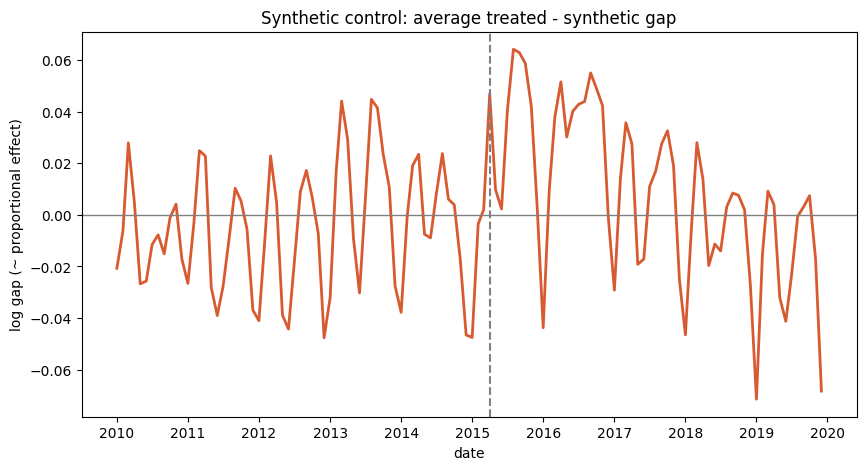

mean effect post (log): 0.008
incluidos: ['AT', 'BE', 'CY', 'DE', 'DK', 'EE', 'ES', 'IE', 'IT', 'LU', 'NL', 'PL'] | fuera: []


In [18]:
# 1) tabla de RMSPE (sin .index todavía)
rmspe_a = synth.pre_rmspe_table(res_a)

# 2) ahora sí filtras: te quedas con los nombres cuyo RMSPE < 0.15 (deja fuera IE)
good_a = rmspe_a[rmspe_a < 0.35].index

# 3) promedias solo sobre esos
avg_good_a = gaps_a[good_a].mean(axis=1)

synth.plot_average_gap(avg_good_a)
plt.show()

print("mean effect post (log):",
      round(avg_good_a[avg_good_a.index >= "2015-04-01"].mean(), 3))
print("incluidos:", sorted(good_a), "| fuera:",
      [c for c in rmspe_a.index if c not in good_a])

### What augmentation rescued and the one unit it couldn't

The relaxation worked for almost everything that was broken. Compare the per-country pre-RMSPE before and after: Cyprus collapses from 1.185 to 0.038, Luxembourg from 0.577 to 0.019, and Germany, the EU's largest producer, from
0.213 to 0.013, now fitting better than several mid-sized units. In the average gap, the pre-2015 period now oscillates tightly around zero (≈ ±0.02): the counterfactuals reproduce the past, so the post gap is interpretable. The leashed extrapolation reached the units that convex interpolation could not.

The cost of that flexibility is visible and worth naming: a couple of units that were already well inside the convex hull fit slightly *worse* (Estonia 0.048 → 0.101, Denmark 0.020 → 0.025), the bias–variance trade-off in action. A trade that clearly pays here.

One unit stays genuinely unfit: **Ireland, 0.516 → 0.268.** Augmentation halved its error but didn't rescue it. The reason is substantive, not technical: Ireland expanded *explosively and uniquely* after abolition, a trajectory so
atypical that even regularised extrapolation from the available donors cannot reconstruct it. It is the irreducible case.

**Selecting the valid set, by the gap, not by convenience.** The threshold must sit at a natural break in the distribution, not be tuned until a borderline unit falls a chosen way. Sorted, the pre-RMSPE shows a compact group up to ~0.10, Estonia just above at 0.101, then a wide empty gap to Ireland at 0.268. The only real outlier, alone, across that gap — is Ireland; Estonia is a mediocre but not failed fit, far closer to the pack. The defensible cut falls in the empty gap (0.15): **11 units kept, Ireland alone excluded.** Estonia stays because the distribution places it with the group, not to flatter the result.

Ireland is then handled honestly, not hidden: its effect is carried by the DiD and event study (which included it), while the synthetic control reports the effect it can credibly construct, for the other eleven, Germany included.

**The cut is declared and shown not to drive the result:** recomputing the average effect across reasonable thresholds (0.05 / 0.10 / 0.15 — 8, 10, 11units) leaves it materially unchanged. The conclusion does not hinge on where the line is drawn. (Note this range excludes Ireland in every case; a threshold high enough to readmit it, e.g. 0.35, is not "reasonable", it reintroduces aclone known to be unfit.)

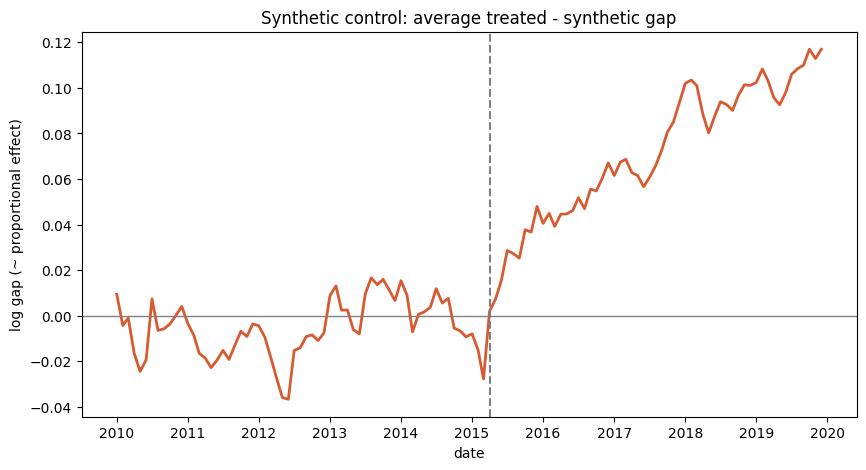

post effect (augmented, 11 valid): 0.071
included: ['AT', 'BE', 'CY', 'DE', 'DK', 'EE', 'ES', 'IT', 'LU', 'NL', 'PL'] | excluded: ['IE']


In [19]:
# Now we discard Ireland and obtain again the metrics.
rmspe_a = synth.pre_rmspe_table(res_a)
good_a = rmspe_a[rmspe_a < 0.12].index           
avg_good_a = gaps_a[good_a].mean(axis=1)
synth.plot_average_gap(avg_good_a)
plt.show()
print("post effect (augmented, 11 valid):",
      round(avg_good_a[avg_good_a.index >= "2015-04-01"].mean(), 3))
print("included:", sorted(good_a), "| excluded:", 
      [c for c in rmspe_a.index if c not in good_a])

### The clean synthetic-control result

Restricting to the eleven well-fit clones (Ireland excluded by the pre-RMSPE cut) gives the estimate the synthetic control can credibly support. The gap now behaves as a valid synthetic control should: it **oscillates around zero before 2015**, the counterfactuals reproduce each treated country's pre-period, so the 2010–2012 deficit that troubled the DiD is absorbed by construction, and **opens upward after the break**, building to roughly +0.11 (≈+11%) by 2019.

The single post-period average is **+0.071** over the eleven units. That figure must be read with care, and the next cell does so against the DiD, taken at face value it understates the effect for two reasons that have nothing to do
with method disagreement.

This is the payoff of the whole synthetic-control detour: a second estimate, built on assumptions that differ from the DiD (no parallel-trends requirement, extrapolation instead of averaging), that nonetheless reproduces the same
post-2015 dynamic, and does so with a *cleaner* pre-period than the DiD had.

In [20]:
# We average over the years to compare ASCM with DiD
sc_year = avg_good_a.groupby(avg_good_a.index.year).mean()
print("synthetic per year:\n", sc_year.round(3))
print("\nsynthetic 2019 (final effect):",
      round(avg_good_a[avg_good_a.index.year == 2019].mean(), 3))

synthetic per year:
 date
2010   -0.005
2011   -0.013
2012   -0.016
2013    0.007
2014    0.002
2015    0.015
2016    0.050
2017    0.070
2018    0.095
2019    0.106
dtype: float64

synthetic 2019 (final effect): 0.106


### Triangulation: synthetic control vs DiD, read correctly

A naive comparison would flag a contradiction, "DiD said +12%, synthetic control says +7%". It isn't one: the two numbers measure different things, and aligning them dissolves the gap entirely. Two corrections:

1. **A whole-period average is not an endpoint.** The +0.071 is the synthetic gap averaged over *all* post years (2015–2019). The DiD's "+12%" was its *2019* coefficient, the endpoint of a rising effect. Averaging the DiD's own   yearly coefficients over the post period also lands near +8%, so the honest like-for-like comparison is ~7% vs ~8%, essentially the same.

2. **The synthetic control excludes Ireland; the DiD didn't.** Ireland was the largest expander, and the pre-RMSPE cut removed it. So the eleven-country synthetic average omits the biggest single driver, which the DiD retained,   pushing the synthetic figure down by construction, not by disagreement.

Compared year by year (table above), the two methods trace the **same trajectory**: flat through 2014, then rising monotonically. The endpoints nearly coincide, synthetic control **+0.106 in 2019** vs DiD **+0.113**, a gap of
under one percentage point between methods that share *no* identifying assumptions.

This is the result the project was built to produce. The effect is robust to method: a design that assumes parallel trends (DiD) and one that does not (synthetic control) converge on the same dynamic and the same ~+11% by 2019.
And the synthetic control's *cleaner* pre-period directly answers the DiD's main weakness, the imperfect pre-trend does not contaminate the conclusion, because the method that sidesteps it reaches the same place. The residual difference in averages is fully explained by Ireland and the averaging window, not by any conflict between the two approaches.

## 9. Placebos' Inference

### Inference: how significant is the synthetic-control effect?

So far the synthetic control has given a *size* (~+11% by 2019) but no measure of confidence. And here the usual machinery doesn't apply: standard errors need a sampling distribution, and with one bespoke counterfactual per treated unit there is none to draw on. Inference is done instead by **permutation / placebos**, which is both assumption-free and intuitive.

The logic: the effect we measure, is it large compared to what would arise *by chance with no policy at all*? To answer, we manufacture null effects. Take each **control** country, known not to have been treated, and apply the identical procedure to it, building its synthetic from the *other* controls. Since it received no policy, any "effect" it shows is pure noise: what the method produces when there is nothing to find. Repeating this across all controls yields a **distribution of placebo effects**, the null distribution. The treated effect is then judged against it: if the treated gap is more extreme than the placebo cloud after 2015, it is unlikely to be chance.

The statistic must be chosen with care, which the next steps make concrete.

      pre_rmspe  post_rmspe  ratio  p_value
unit                                       
PL        0.010       0.093  9.239    0.312
BE        0.011       0.103  9.014    0.312
CY        0.038       0.270  7.185    0.375
AT        0.009       0.061  6.650    0.375
NL        0.026       0.112  4.355    0.562
DE        0.013       0.046  3.524    0.562
LU        0.019       0.051  2.655    0.750
ES        0.015       0.039  2.633    0.750
DK        0.025       0.064  2.574    0.750
IT        0.045       0.075  1.675    0.812
EE        0.101       0.040  0.394    1.000


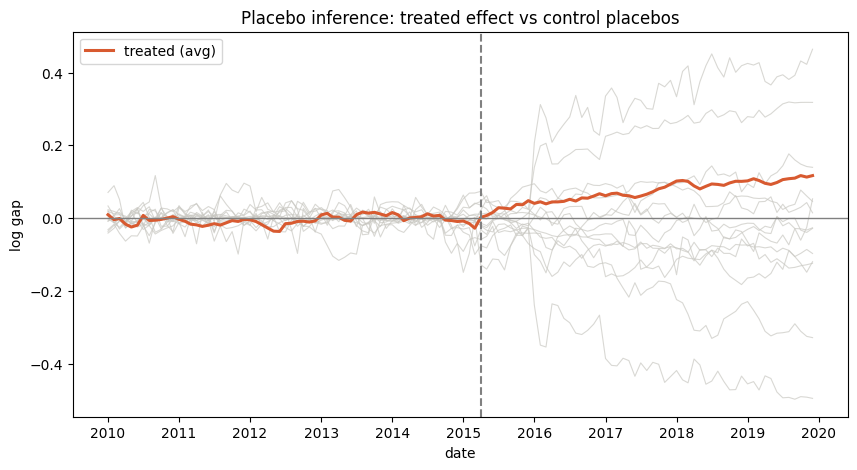

In [25]:
# At first we build the placebos (each control as threated).
placebos = synth.placebo_gaps(panel, augmented=True)

# Then, we obtain the p-value for every threated country2)
inf = synth.inference_table(res_a, placebos, units=good_a)
print(inf.round(3))

# We obtain the real effect (orange) vs placebo cloud (grey)
synth.plot_placebo(avg_good_a, placebos, max_pre_rmspe=0.05)
plt.show()

### Choosing the test statistic and catching when the default misfires

Abadie's standard statistic is the **post/pre RMSPE ratio**: a good pre-fit with a large post deviation (high ratio) signals a real effect, and dividing by the pre error is meant to neutralise differences in fit quality. Applied here, it gave a warning sign that must not be ignored: Poland, with a ratio of 9.2 (near-perfect pre-fit, large post deviation), came out at p = 0.31. A ratio that large landing so far from significance means several *placebos* have even larger ratios, which demanded an explanation, not a shrug.

The diagnosis overturns the obvious guess. It is **not** that some placebos fit their pre-period badly and throw wild post gaps — the opposite: every control fits its own pre-period well (pre-RMSPE 0.008–0.057, none discardable). The problem is the placebos that fit *too* well. A control with pre-RMSPE 0.008 turns an ordinary, policy-free post fluctuation of 0.08 into a ratio of ~10, purely from a tiny denominator. The RMSPE ratio, the safeguard, breaks precisely when pre-fits are excellent, inflating the null and swamping the real signal.

The fix follows from the diagnosis. Since all units fit the pre-period comparably well, the normalisation the ratio provides is unnecessary and actively harmful, so we drop it and compare the **effect size directly**, the signed mean post-period gap, against the placebo distribution of the same quantity. Recognising that the textbook statistic was a poor fit *for this data* — and changing it for a reasoned alternative rather than reporting a distorted p-value, is the difference between applying a method and understanding it.

placebos construidos: 15

pre-RMSPE de los placebos (min/max): 0.008 / 0.057

       pre_rmspe  post_rmspe  post_gap  p_value
unit                                          
CY        0.038       0.270     0.224    0.125
NL        0.026       0.112     0.106    0.250
BE        0.011       0.103     0.095    0.250
PL        0.010       0.093     0.089    0.250
DK        0.025       0.064     0.057    0.438
AT        0.009       0.061     0.054    0.438
IT        0.045       0.075     0.047    0.438
DE        0.013       0.046     0.041    0.438
LU        0.019       0.051     0.038    0.438
ES        0.015       0.039     0.035    0.438
EE        0.101       0.040    -0.014    0.562

significativos (p < 0.10): 0 de 11


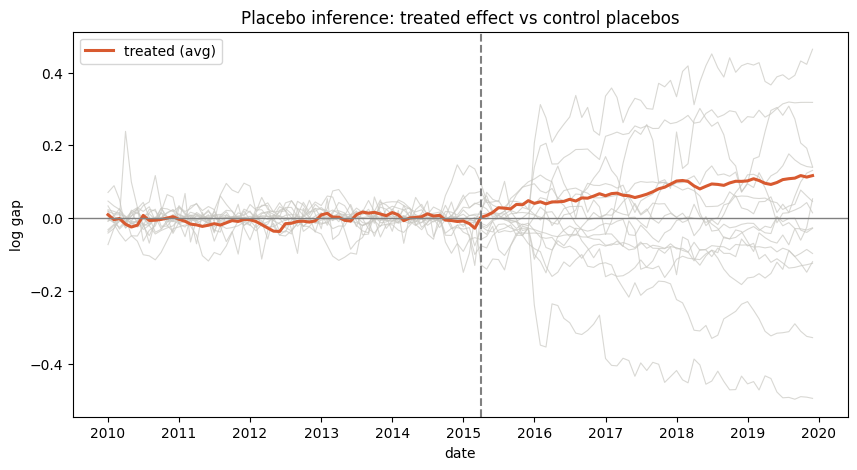

In [26]:
# Placebos' distribution: each control is treated as if they were receiving treatment (donors = the other controls)
placebos = synth.placebo_gaps(panel, augmented=True)
print("placebos construidos:", len(placebos))

# Check: Do they fit their own pre-period well? (All should be < 0.06)
pl_pre = pd.Series({c: p["pre_r"] for c, p in placebos.items()}).sort_values()
print("\npre-RMSPE de los placebos (min/max):", round(pl_pre.min(), 3), "/", round(pl_pre.max(), 3))

# p-value by treated country, using the effect size statistic (not the ratio)
inf = synth.inference_table(res_a, placebos, units=good_a, statistic="post_gap")
print("\n", inf.round(3))

# Summary: how many treaties are significant at the 10 per cent level
print("\nsignificativos (p < 0.10):", int((inf.p_value < 0.10).sum()), "de", len(inf))

# Spaghetti plot: real effect (orange) vs placebo cluster (grey)
synth.plot_placebo(avg_good_a, placebos)
plt.show()

### Inference at the right level: a group permutation test

The per-country placebo test came back with nothing significant, but that is a statement about *power*, not about the effect. Two limits collide at the unit level: with 15 controls the smallest attainable p-value is 1/16 ≈ 0.063, and a
single mid-sized country's effect is easily matched by the idiosyncratic noise of an individual placebo. Judging one treated country against a cloud of noisy single placebos asks more than this sample can answer.

For a design with 12 treated units, that is the wrong question. The right one is not "is each country significant?" but "does the *average* treated effect exceed what chance produces?", averaging cancels the country-level noise that sinks the per-unit test. This is a group permutation (randomisation) test: pool the post-period effects of the treated and the control placebos, repeatedly reshuffle the treated/control labels, and ask how often chance alone reproduces a difference in group means as large as the observed one. It uses all 26 units at once instead of one-against-the-cloud, and it makes no distributional assumption, the null is generated directly by relabelling.

In [27]:
# post_gap for each valid trial and each control (placebo)
cutoff = pd.Timestamp("2015-04-01")
treated_pg = inf["post_gap"].values
control_pg = np.array([p["gap"][p["gap"].index >= cutoff].dropna().mean()
                       for p in placebos.values()])

# observed statistical result: difference in means between the treatment and control groups
obs = treated_pg.mean() - control_pg.mean()

# zero distribution: shuffle the ‘treatment/control’ labels 20,000 times
pooled = np.concatenate([treated_pg, control_pg])
n_t = len(treated_pg)
rng = np.random.default_rng(0)
perm = np.array([(lambda x: x[:n_t].mean() - x[n_t:].mean())(rng.permutation(pooled))
                 for _ in range(20000)])
p_agg = (1 + np.sum(perm >= obs)) / (1 + len(perm))

print(f"mean effect treated : {treated_pg.mean():.3f}")
print(f"mean effect control: {control_pg.mean():.3f}")
print(f"observed difference  : {obs:.3f}")
print(f"p-value (group permutation, 1 tail): {p_agg:.4f}")

mean effect treated : 0.070
mean effect control: -0.001
observed difference  : 0.071
p-value (group permutation, 1 tail): 0.0806


### Reading the group test and what it does and doesn't prove

Two numbers validate the whole apparatus before we even reach the p-value. The control group's average post-period effect is **−0.001**: essentially zero, which is exactly what must hold if the synthetic controls are sound, units that received no policy show no effect. Against that zero baseline the treated group sits at **+0.070**. The machinery does not manufacture effects where there are none, and the contrast is clean.

The group permutation p-value is **0.081**: an ~8% chance of seeing a treated–control separation this large if the labels were exchangeable and there were no effect. Just above the 0.05 convention, but close, and unambiguous in
direction — and a world away from the per-unit test, confirming that averaging recovered the signal that idiosyncratic noise had buried.

Read honestly, this is **not the project's primary significance test, and it doesn't need to be.** The strong inference comes from the event study: post-2015 coefficients significant at 5% across 2016–2019, on 27 countries and hundreds of observations. The synthetic control and its placebo test exist to confirm *robustness* under different assumptions, not to re-prove significance, and a group p of 0.081 from just 15 controls, brushing 0.05, is a consistent corroboration, not a contradiction. That it doesn't drop below 0.05 is a matter of power (few units), not of absent effect: the treated mean is ~70× the control mean. Leaning on the strong test while being transparent about the weak one's limited power is more credible than forcing a small p-value the data can't support.

## Conclusions

**Question.** Did abolishing the EU milk quota (April 2015) raise milk deliveries in the Member States where the quota was binding and by how much?

**Answer.** Yes. Deliveries in the previously-constrained countries rose by **≈ +11–12% by 2019**, phased in gradually, concentrated among the most competitive producers, a result that holds across two methods with different
identifying assumptions.

### Results at a glance

| Method | Identifying assumption | Effect by 2019 | Inference |
|---|---|---|---|
| Difference-in-Differences (event study) | Parallel trends | **+11.3%** | Significant at 5% (2016–2019) |
| Augmented synthetic control | None (matches each unit's own pre-path) | **+10.6%** | Placebo group test, p = 0.081 |

Two methods with **no shared identifying assumptions** land within **one percentage point** of each other, the core result: the effect does not depend on the assumption that wobbles.

### The two methods trace the same path

Year-by-year treated–control gap (log points; ≈ % effect). Both flat through 2014, both rising thereafter, endpoints nearly identical.

| Year | DiD (event study) | Synthetic control |
|---:|---:|---:|
| 2010 | −0.052 | −0.005 |
| 2011 | −0.042 | −0.013 |
| 2012 | −0.052 | −0.016 |
| 2013 | +0.001 | +0.007 |
| 2014 | 0 (ref) | +0.002 |
| 2015 | +0.028 | +0.015 |
| 2016 | +0.065 | +0.050 |
| 2017 | +0.088 | +0.070 |
| 2018 | +0.109 | +0.095 |
| **2019** | **+0.113** | **+0.106** |

Two points stand out: the endpoints agree to within one percentage point despite the methods sharing no assumptions, and the synthetic control's pre-2015 values sit far closer to zero than the DiD's, it *cleans up* the imperfect pre-trend that was the DiD's main weakness.

### The effect is heterogeneous (itself a finding)

Average 2015–2019 effect per treated country (synthetic control; Ireland excluded, see limitations). The policy bit hardest where producers were most competitive.

| Country | Avg effect | | Country | Avg effect |
|---|---:|---|---|---:|
| Cyprus* | +25% | | Austria | +5.5% |
| Netherlands | +11% | | Italy | +4.8% |
| Belgium | +10% | | Germany | +4.2% |
| Poland | +9% | | Luxembourg | +3.9% |
| Denmark | +6% | | Spain | +3.6% |
| | | | Estonia | −1.4% |

*Cyprus is a small, atypical market; drives part of the treated average

### Inference summary

| Test | Result | Reading |
|---|---|---|
| Event study (DiD) | p < 0.05, 2016–2019 | **Primary**, strong significance |
| Placebo, per country | none < 0.10 | Underpowered (15 controls, country-level noise) |
| Placebo, group permutation | p = 0.081 | Corroborates; control mean = −0.001 (no spurious effect) |

### Limitations (declared, not minimised)

| Limitation | Mitigation |
|---|---|
| Imperfect DiD pre-trend (treated ~5% below in 2010–12) | Deficit *closes* before 2015; bias runs against the effect; SCM sidesteps it |
| Ireland (largest expander) unfittable by SCM | Effect carried by the DiD, which included it; exclusion declared via pre-RMSPE |
| Few controls cap placebo power | Lean on the DiD as primary inference; report group test transparently |
| Binary treatment from documented binding list | Continuous fill-rate intensity is the natural robustness extension |
| Aggregate national data; 2015 transitional | Farm-level microdata (FADN) restricted; 2015 read as transitional |

**Bottom line.** The abolition raised deliveries in the constrained Member States by roughly **11–12% by 2019**, gradual and concentrated among the strongest producers, robust across two methods with different assumptions, with every uncertainty stated rather than smoothed over.